In [17]:
!pip install openpyxl

Chargement des données de la Banque de France...
Succès ! 19 périodes temporelles consolidées.


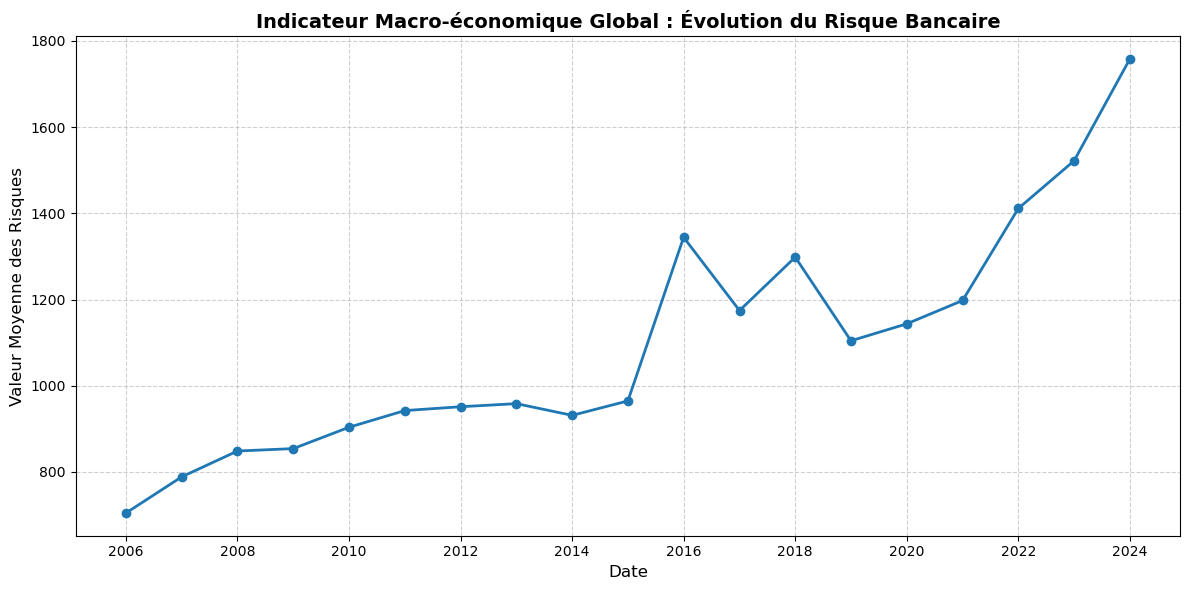

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# On cache les alertes mineures
warnings.filterwarnings("ignore")

print("Chargement des données de la Banque de France...")

try:
    # 1. LE CORRIGÉ EST ICI : sep=';' et encoding='utf-8-sig' pour retirer le ï»¿
    df = pd.read_csv('donnees_banque_france.csv', sep=';', encoding='utf-8-sig', low_memory=False)

    # 2. Cadrage sur tes vraies colonnes (dates et valeurs)
    df['Date'] = pd.to_datetime(df['time_period_start'], errors='coerce')
    
    # 3. Traitement des valeurs : Remplacement des virgules par des points
    df['Valeur'] = df['obs_value'].astype(str).str.replace(',', '.', regex=False).str.replace(' ', '', regex=False)
    df['Valeur'] = pd.to_numeric(df['Valeur'], errors='coerce')

    # 4. Nettoyage et Agrégation
    df_clean = df.dropna(subset=['Date', 'Valeur'])
    
    # La Banque de France donne des séries par sous-catégories (crédit, immo...). 
    # On moyenne le tout par date pour créer un indicateur Macro-économique.
    df_trend = df_clean.groupby('Date')['Valeur'].mean().reset_index()
    df_trend = df_trend.sort_values(by='Date')

    if df_trend.empty:
        print("Erreur : Le tableau est vide après le nettoyage.")
    else:
        print(f"Succès ! {len(df_trend)} périodes temporelles consolidées.")

        # 5. Datavisualisation
        plt.figure(figsize=(12, 6))
        plt.plot(df_trend['Date'], df_trend['Valeur'], marker='o', color='#1f77b4', linewidth=2)

        plt.title("Indicateur Macro-économique Global : Évolution du Risque Bancaire", fontsize=14, fontweight='bold')
        plt.xlabel("Date", fontsize=12)
        plt.ylabel("Valeur Moyenne des Risques", fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()

        # Sauvegarde automatique
        plt.savefig('evolution_risque.png', dpi=300)
        plt.show()

except Exception as e:
    print(f"Erreur technique : {e}")

Analyse Métier : L'Indicateur Macro-économique de Risque

Ce graphique représente la création d'un indicateur global de "Tension Bancaire" en France (2006-2024), synthétisé à partir de multiples sous-catégories de l'Open Data institutionnelle.

Le constat visuel : On observe une tendance de fond à la hausse des risques moyens, avec des pics de volatilité marqués (notamment autour de 2016-2017 et une accélération forte après 2020).

L'utilité métier (Le "Pourquoi") : En finance, évaluer un dossier de crédit nécessite de comprendre l'environnement global. Un emprunteur avec un profil moyen est beaucoup plus susceptible de faire défaut si l'économie nationale se crispe. Ce travail de Data Engineering permet de transformer une donnée macro-économique complexe en une variable simple (un indicateur d'environnement) directement injectable dans un modèle d'Intelligence Artificielle.

La valeur pour l'entreprise : Au lieu de piloter le risque "à l'aveugle" en se basant uniquement sur les fiches de paie des clients, l'entreprise bancaire possède désormais un "thermomètre" du marché. Cela permet d'ajuster dynamiquement les politiques commerciales.

Problématiques et Stratégie Data

Pourquoi avoir moyenné les données plutôt que de garder les 29 variables originales ?
L'objectif est la réduction du bruit (Dimensionality Reduction). Garder 29 variables économiques très corrélées entre elles risque de créer de la confusion (colinéarité) dans un modèle prédictif. En les agrégeant, on extrait le signal fondamental du marché (la tendance générale du risque) sans alourdir l'algorithme.

Comment cette courbe s'intègre-t-elle concrètement au projet de Credit Scoring ?
C'est une étape de Feature Engineering. Lors de l'entraînement du modèle final (ex: Random Forest), chaque profil client se verra attribuer le "Score Macro-économique" correspondant à l'année de sa demande de prêt. L'algorithme apprendra ainsi à durcir ses critères d'acceptation lors des années où la tension bancaire globale est élevée.

Que nous dicte la tendance récente (2020-2024) sur les décisions à prendre ?
La pente abrupte des dernières années indique une dégradation rapide de l'environnement de crédit. Face à ce signal, un Data Scientist recommandera à la direction des risques d'augmenter le seuil de probabilité (threshold) requis par l'algorithme pour accepter automatiquement un crédit, afin de protéger les liquidités de la banque en période d'incertitude.